In [1]:
import pandas as pd
df = pd.read_csv('diabetes_prediction_dataset.csv')
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [2]:
df.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64


Confusion Matrix:
[[17024  1268]
 [  620  1088]]


Accuracy: 0.9056


Precision: 0.4617996604414261


Recall: 0.6370023419203747


F1 Score: 0.5354330708661418




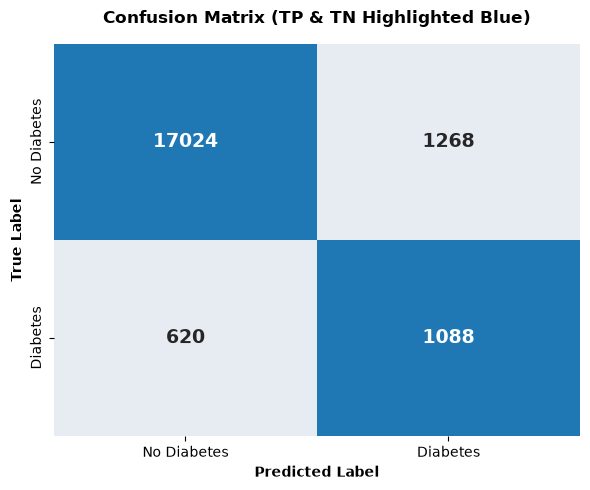

In [1]:
"""
File : NaiveBayes.py
DATE : 2026-08-18
Day : Tuesday
author : Shubham Khedkar
assignment03 : Based on Naive Bayes Classifier 
"""

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pylab as plt
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

# Load and preprocess dataset
df = pd.read_csv('diabetes_prediction_dataset.csv')
data = df[['gender', 'age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']]
data['gender'] = data['gender'].map({'Male': 0, 'Female': 1, 'Other': 2})

x = data.drop('diabetes', axis=1)
y = data['diabetes']

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

# Train Gaussian Naive Bayes Model
model = GaussianNB()
model.fit(x_train, y_train)

# Model Predictions
y_pred = model.predict(x_test)

# Calculate Confusion Matrix
confusion = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(confusion)
print("\n")

# Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("\n")

precision = precision_score(y_test, y_pred)
print("Precision:", precision)
print("\n")

recall = recall_score(y_test, y_pred)
print("Recall:", recall)
print("\n")

f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)
print("\n")

# --- Graphical Confusion Matrix (TP and TN in Blue) ---

# Color mask: 1 = Blue (for TN at [0,0] and TP at [1,1]), 0 = Light Gray (for FP and FN)
color_mask = np.array([
    [1, 0],
    [0, 1]
])

plt.figure(figsize=(6, 5))

sns.heatmap(
    color_mask, 
    annot=confusion,              # Overlay original prediction numbers
    fmt='d',                      # Format counts as integers
    cmap=['#e6ecf2', '#1f77b4'],  # Custom colors: [Light Gray/White, Steel Blue]
    cbar=False,                   # Disable colorbar
    annot_kws={"size": 14, "weight": "bold"}, # Text size for counts
    xticklabels=['No Diabetes', 'Diabetes'],
    yticklabels=['No Diabetes', 'Diabetes']
)

plt.xlabel('Predicted Label', fontweight='bold')
plt.ylabel('True Label', fontweight='bold')
plt.title('Confusion Matrix (TP & TN Highlighted Blue)', pad=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [3]:
df.shape

(100000, 9)